# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [45]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

for name, model in base_models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro')
    mean_f1 = cv_scores.mean()
    std_f1 = cv_scores.std()
    baseline_results[name] = (mean_f1, std_f1)

# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [47]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf', 'linear']
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_grid_search = GridSearchCV(
    estimator=svm_pipe,
    param_grid=svm_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [48]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
results_df = pd.DataFrame(svm_grid_search.cv_results_)
columns_to_show = ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
top_results = results_df[columns_to_show]
top_10 = top_results.sort_values(by='rank_test_score').head(10)

print("Top 10 SVM Configurations:")
print(top_10)

Top 10 SVM Configurations:
                                               params  mean_test_score  \
14  {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...         0.978633   
1   {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...         0.976215   
5   {'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...         0.976215   
3   {'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...         0.976215   
22  {'svm__C': 100, 'svm__gamma': 0.001, 'svm__ker...         0.976157   
16  {'svm__C': 10, 'svm__gamma': 0.001, 'svm__kern...         0.971340   
6   {'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...         0.969357   
12  {'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...         0.969350   
20  {'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern...         0.966936   
8   {'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...         0.966732   

    std_test_score  rank_test_score  
14        0.017581                1  
1         0.015266                2  
5         0.015266                2  
3     

## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [49]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    'n_estimators': randint(50, 500),                        
    'max_depth': randint(2, 20),                    
    'min_samples_split': randint(2, 20),                         
    'max_features': ['sqrt', 'log2', 0.5]
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=50,
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

print(f"std: {rf_random_search.cv_results_['std_test_score'][rf_random_search.best_index_]:.4f}")

KeyboardInterrupt: 

## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [ ]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
y_pred_svm = svm_grid_search.predict(X_test)
print("Classification Report: SVM (Grid Search)")
print(classification_report(y_test, y_pred_svm))

y_pred_rf = rf_random_search.predict(X_test)
print("\nClassification Report: Random Forest (Random Search)")
print(classification_report(y_test, y_pred_rf))

test_f1_svm = f1_score(y_test, y_pred_svm, average='macro')
test_f1_rf = f1_score(y_test, y_pred_rf, average='macro')

print(f"Test F1 (SVM GS): {test_f1_svm:.4f}")
print(f"Test F1 (RF RS): {test_f1_rf:.4f}")

from sklearn.metrics import f1_score

# SVM baseline
base_models['SVM'].fit(X_train, y_train)
svm_test_baseline = f1_score(
    y_test,
    base_models['SVM'].predict(X_test),
    average='macro'
)

# Random Forest baseline
base_models['RandomForest'].fit(X_train, y_train)
rf_test_baseline = f1_score(
    y_test,
    base_models['RandomForest'].predict(X_test),
    average='macro'
)

print(f"Test F1 (SVM BL): {svm_test_baseline:.4f}")
print(f"Test F1 (RF BL): {rf_test_baseline:.4f}")

# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          | 0.9694 ± 0.0193  |    -    |
# | SVM Grid Search       | 0.9786 ± 0.0176  | 0.9812  |
# | RF baseline           | 0.9504 ± 0.0255  |    -    |
# | RF Random Search      | 0.9554 ± 0.0204  | 0.9526  |

summary = pd.DataFrame({
    "Модель": [
        "SVM baseline",
        "SVM Grid Search",
        "RF baseline",
        "RF Random Search"
    ],
    
    "CV F1 (mean±std)": [
        f"{baseline_results['SVM'][0]:.4f} ± {baseline_results['SVM'][1]:.4f}",
        f"{svm_grid_search.best_score_:.4f} ± {svm_grid_search.cv_results_['std_test_score'][svm_grid_search.best_index_]:.4f}",
        f"{baseline_results['RandomForest'][0]:.4f} ± {baseline_results['RandomForest'][1]:.4f}",
        f"{rf_random_search.best_score_:.4f} ± {rf_random_search.cv_results_['std_test_score'][rf_random_search.best_index_]:.4f}"
    ],
    
    "Test F1": [
        f"{svm_test_baseline:.4f}",
        f"{test_f1_svm:.4f}",
        f"{rf_test_baseline:.4f}",
        f"{test_f1_rf:.4f}"
    ]
})

summary

Classification Report: SVM (Grid Search)
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Classification Report: Random Forest (Random Search)
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Test F1 (SVM GS): 0.9812
Test F1 (RF RS): 0.9526
Test F1 (SVM BL): 0.9812
Test F1 (RF BL): 0.9526


,Модель,CV F1 (mean±std),Test F1
0,SVM baseline,0.9694 ± 0.0193,0.9812
1,SVM Grid Search,0.9786 ± 0.0176,0.9812
2,RF baseline,0.9504 ± 0.0255,0.9526
3,RF Random Search,0.9554 ± 0.0204,0.9526


## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

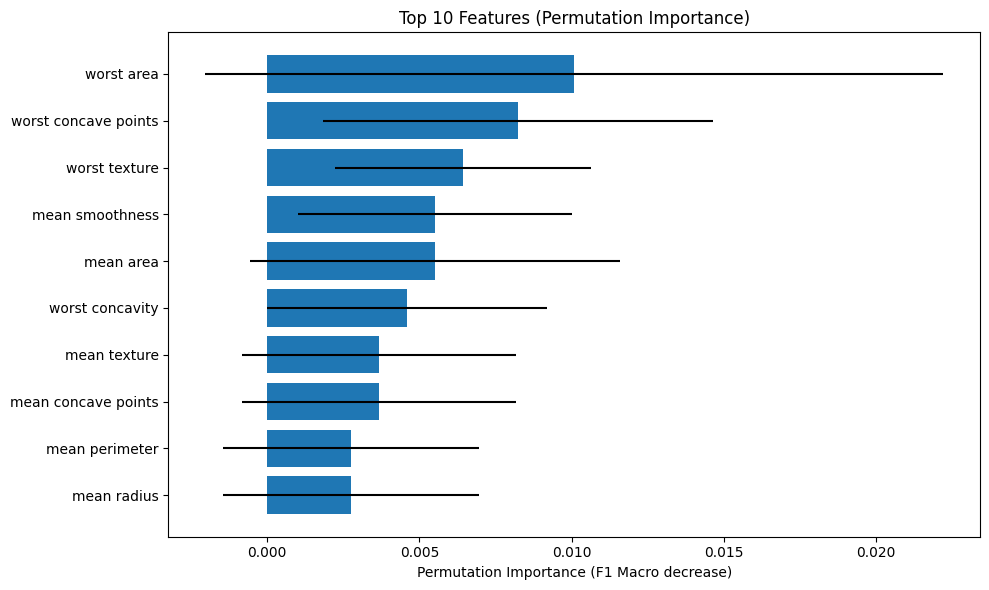

In [ ]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
pi_result = permutation_importance(
    best_rf, X_test, y_test, 
    n_repeats=10, 
    random_state=42, 
    scoring='f1_macro'
)

# Подготовка данных для визуализации
sorted_idx = pi_result.importances_mean.argsort()[-10:]  # Топ-10
feature_names = X_test.columns if hasattr(X_test, 'columns') else [f'f{i}' for i in range(X_test.shape[1])]

# Построим bar plot топ-10 признаков
# YOUR CODE HERE
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), pi_result.importances_mean[sorted_idx], xerr=pi_result.importances_std[sorted_idx])
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.xlabel("Permutation Importance (F1 Macro decrease)")
plt.title("Top 10 Features (Permutation Importance)")
plt.tight_layout()
plt.show()

In [ ]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
mdi_importances = best_rf.feature_importances_
mdi_indices = mdi_importances.argsort()[-5:][::-1]
pi_indices = pi_result.importances_mean.argsort()[-5:][::-1]

print("Топ-5 (Встроенная важность - MDI):", [feature_names[i] for i in mdi_indices])
print("Топ-5 (Permutation Importance):  ", [feature_names[i] for i in pi_indices])

# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?
# высокий PI при низкой встроенной важности — сложные зависимости между признаками (нелинейные)
# наоборот — переобучение (изменения в данных слабо влияют на результат)

Топ-5 (Встроенная важность - MDI): ['worst area', 'worst perimeter', 'worst concave points', 'worst radius', 'mean concave points']
Топ-5 (Permutation Importance):   ['worst area', 'worst concave points', 'worst texture', 'mean smoothness', 'mean area']


## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

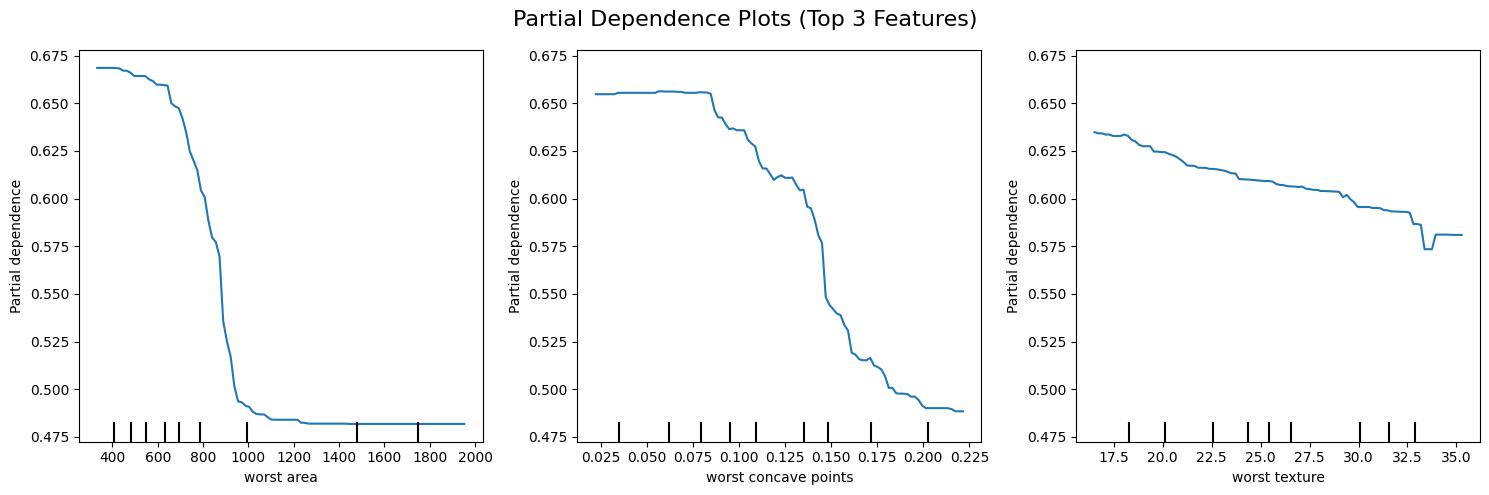

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
top3_idx = pi_result.importances_mean.argsort()[-3:][::-1]

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

PartialDependenceDisplay.from_estimator(
    estimator=best_rf,
    X=X_test, 
    features=top3_idx, # передаем индексы самых важных признаков
    kind='average',    # строим именно PDP (усредненную линию)
    ax=ax              # рисуем в созданные подобъекты
)

plt.suptitle("Partial Dependence Plots (Top 3 Features)", fontsize=16)
plt.tight_layout()
plt.show()

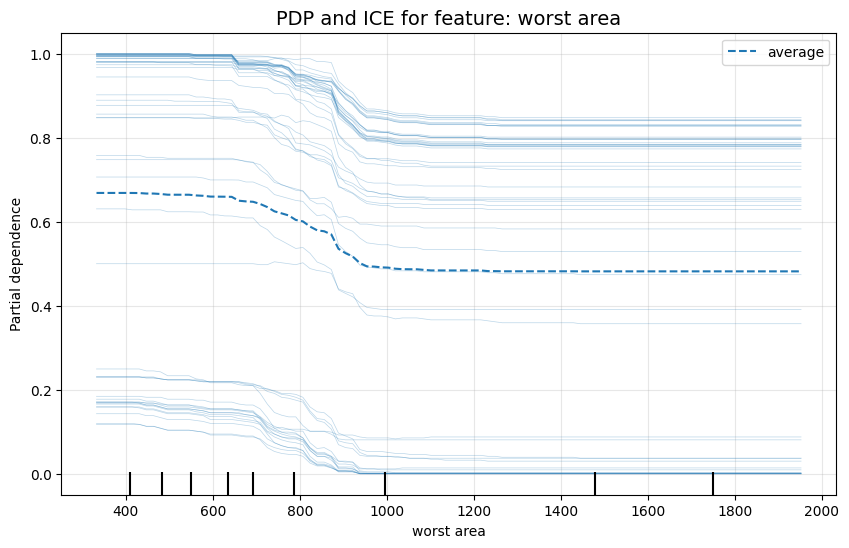

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)   ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
best_feature_idx = pi_result.importances_mean.argmax()
fig, ax = plt.subplots(figsize=(10, 6))

PartialDependenceDisplay.from_estimator(
    estimator=best_rf,
    X=X_test,
    features=[best_feature_idx],
    kind='both',
    subsample=50,
    ax=ax
)

plt.title(f"PDP and ICE for feature: {feature_names[best_feature_idx]}", fontsize=14)
plt.grid(alpha=0.3)
plt.show()

Признак однороден (по графику)

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [ ]:
# Установка SHAP (если не установлен)
%pip install shap

import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)
print(f"Форма shap_values: {np.shape(shap_values)}")

Note: you may need to restart the kernel to use updated packages.
Форма shap_values: (114, 30, 2)


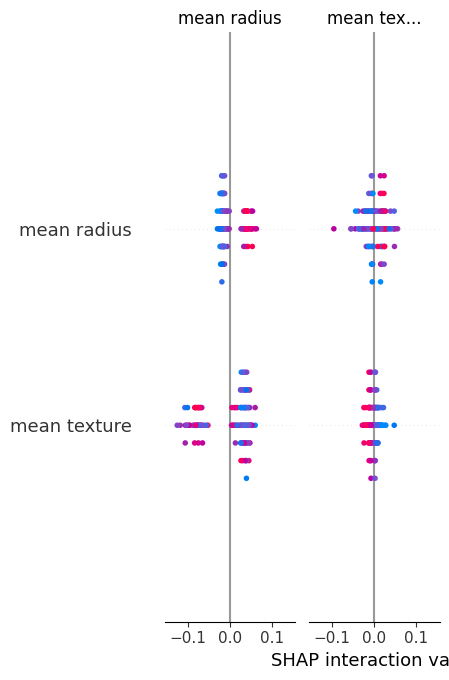

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
shap_val_to_plot = shap_values

shap.summary_plot(shap_val_to_plot, X_test)

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

i = errors[0]
cls = y_pred_test[i]
sv = shap_values[i, :, cls]
expected_value = explainer.expected_value[cls]
x = X_test.iloc[i]
shap.initjs()
shap.plots.force(expected_value, sv, x)


Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0


## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [ ]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

Test F1 на расширенных данных: 1.0000


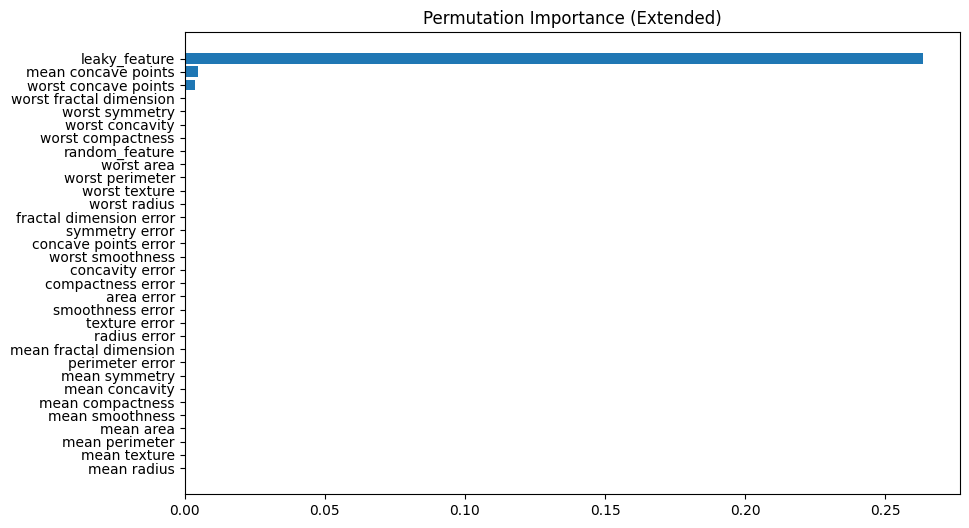

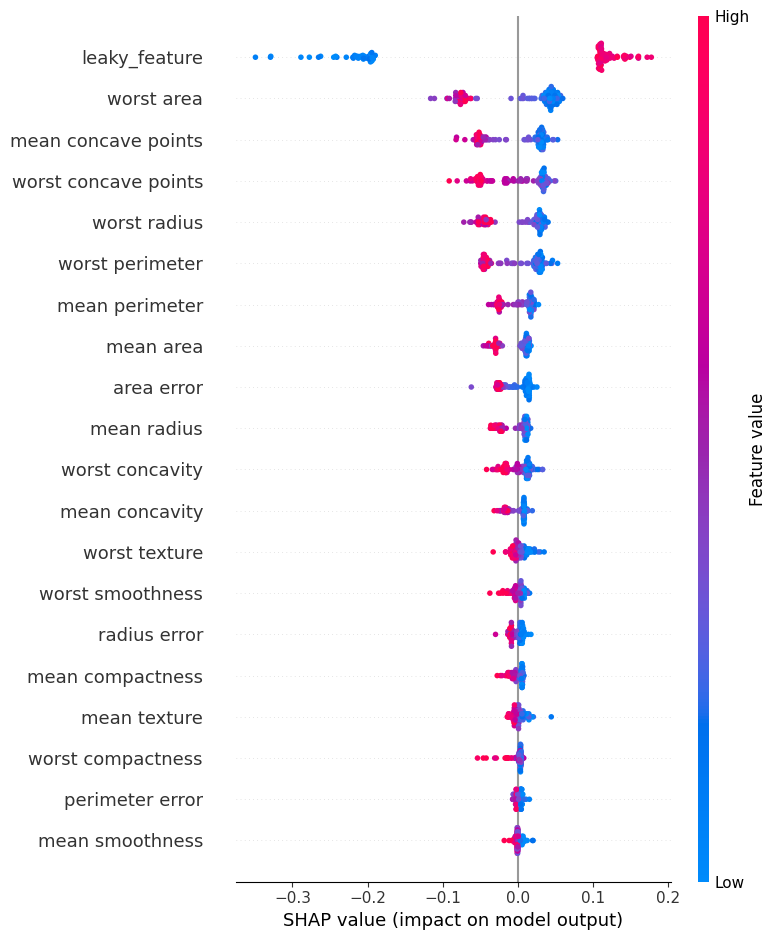

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_ext = RandomForestClassifier(random_state=42)
rf_ext.fit(X_train_ext, y_train)

pi_ext = permutation_importance(
    rf_ext, X_test_ext, y_test, 
    n_repeats=10, random_state=42, scoring='f1_macro'
)

explainer_ext = shap.TreeExplainer(rf_ext)
shap_values_ext = explainer_ext.shap_values(X_test_ext)

print(f"Test F1 на расширенных данных: {f1_score(y_test, rf_ext.predict(X_test_ext), average='macro'):.4f}")

sorted_idx_ext = pi_ext.importances_mean.argsort()
plt.figure(figsize=(10, 6))
plt.barh(X_test_ext.columns[sorted_idx_ext], pi_ext.importances_mean[sorted_idx_ext])
plt.title("Permutation Importance (Extended)")
plt.show()

shap.summary_plot(shap_values_ext[:, :, 1], X_test_ext)

a)
PI определяет leaky_feature как наиболее важный признак, так как он практически совпадает с целевой переменной. Метрика на тесте выросла из-за "утечки таргета", т. е. модель использует правильные ответы как признак.

б)
И в PI-графике, и в summary plot leaky_feature занимает первое место и имеет наибольшие SHAP-значения, что указывает на его доминирующее влияние на предсказания модели.

в)
random_feature можно обнаружить как шумовой признак по низким значениям PI (близким к нулю)

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [ ]:
import pandas as pd

summary = pd.DataFrame({
    "Метод": [
        "SVM baseline",
        "SVM Grid Search",
        "RF baseline",
        "RF Random Search"
    ],
    "CV F1": [
        baseline_results['SVM'][0],
        svm_grid_search.best_score_,
        baseline_results['RandomForest'][0],
        rf_random_search.best_score_
    ],
    "Test F1": [
        svm_test_baseline,
        test_f1_svm,
        rf_test_baseline,
        test_f1_rf
    ],
    "Выводы": [
        "Базовая модель, хорошая",
        "Тюнинг еще улучшил качество",
        "Базовая, довольно сильная модель",
        "Небольшое улучшение"
    ]
})

summary

,Метод,CV F1,Test F1,Выводы
0,SVM baseline,0.969357,0.981151,"Базовая модель, хорошая"
1,SVM Grid Search,0.978633,0.981151,Тюнинг еще улучшил качество
2,RF baseline,0.950427,0.952638,"Базовая, довольно сильная модель"
3,RF Random Search,0.955384,0.952638,Небольшое улучшение


## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

In [50]:
# %pip install optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 2, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5])
    }

    model = RandomForestClassifier(random_state=42, **params)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='f1_macro'
    ).mean()

    return score


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(study.best_value)
print(study.best_params)

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)
# print(f"Лучший результат Optuna: {study.best_value:.4f}")
# print(f"Лучшие параметры: {study.best_params}")

0.9577244086213799
{'n_estimators': 77, 'max_depth': 15, 'min_samples_split': 3, 'max_features': 0.5}
